# v2.1 XGBoost Training: Encrypted DNS & Infrastructure Attacks

**Dataset**: `Attack_and_Benign_balanced_Final_Shuffled.csv`
**Features**: 44 Columns (including new `sni_entropy`, `large_packet_ratio`)
**Goal**: Detect DOH/DOT Tunneling, DNS Amplification, and Volumetric Attacks.

In [23]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Config
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

## 1. Load Data

In [ ]:
FILE_PATH = r"C:\Users\shenal\Downloads\reseraach\PCAPS_Used\Final_Balanced_Attack_and_Benign\Final_balanced_Attack_and_Benign_new_Shuffled.csv"

print(f"[INFO] Loading dataset from: {FILE_PATH}")
df = pd.read_csv(FILE_PATH)
print(f"[SUCCESS] Loaded {len(df):,} rows with {len(df.columns)} columns.")

# Show sample
df.head()

[INFO] Loading dataset from: C:\Users\shenal\Downloads\reseraach\PCAPS_Used\Final_Attacks\Final_benign_Attack\Final_benign_Attack_new_Shuffled.csv
[SUCCESS] Loaded 1,010,037 rows with 45 columns.


,protocol,src_ip,dst_ip,src_port,dst_port,protocol_number,dns_amplification_factor,query_response_ratio,dns_any_query_ratio,dns_txt_query_ratio,dns_response_inconsistency,dns_queries_per_second,port_53_traffic_ratio,flow_bytes_per_sec,flow_packets_per_sec,fwd_packets_per_sec,bwd_packets_per_sec,flow_duration,total_fwd_packets,total_bwd_packets,total_fwd_bytes,total_bwd_bytes,dns_total_queries,dns_total_responses,dns_response_bytes,flow_iat_mean,flow_iat_std,flow_iat_min,flow_iat_max,fwd_iat_mean,bwd_iat_mean,fwd_packet_length_mean,bwd_packet_length_mean,packet_size_std,flow_length_min,flow_length_max,response_time_variance,average_packet_size,large_packet_ratio,medium_packet_ratio,small_packet_ratio,sni_entropy,is_known_doh_server,encrypted_payload_size_variance,label
0,TRADITIONAL,192.168.137.123,192.168.137.123,49424,53,TCP,0.0000,0.0,0.0,0.0,0,0.0,0.0,2.662590e+01,0.4438,0.4438,0.0000,60843,27,0,1620.0,0.0,0,0,0,2340.1154,2197.7801,105.0,9201.0,2340.1154,0.0,60.0000,0.0,0.0000,60.0,60.0,0.0,60.0000,0.0,0.0000,1.0000,0.0,0,0.0,ATTACK
1,TRADITIONAL,192.168.137.1,192.168.137.47,53,51326,UDP,4.3012,1.0,0.0,0.0,0,200.0,1.0,8.800000e+04,400.0000,200.0000,200.0000,5,1,1,357.0,83.0,1,1,357,5.0000,0.0000,5.0,5.0,0.0000,0.0,357.0000,83.0,193.7473,83.0,357.0,0.0,220.0000,0.0,0.0000,1.0000,0.0,0,0.0,BENIGN
2,UNKNOWN,172.16.0.5,192.168.50.1,608,38049,UDP,0.0000,0.0,0.0,0.0,0,0.0,0.0,1.595600e+07,34000.0000,34000.0000,0.0000,1,34,0,15956.0,0.0,0,0,0,0.0303,0.1741,0.0,1.0,0.0303,0.0,469.2941,0.0,51.5878,266.0,482.0,0.0,469.2941,0.0,0.9412,0.0588,0.0,0,0.0,ATTACK
3,UNKNOWN,192.168.137.133,18.182.200.45,27172,32100,UDP,0.0000,0.0,0.0,0.0,0,0.0,0.0,5.446429e+02,8.9286,4.4643,4.4643,224,1,1,60.0,62.0,0,0,0,224.0000,0.0000,224.0,224.0,0.0000,0.0,60.0000,62.0,1.4142,60.0,62.0,0.0,61.0000,0.0,0.0000,1.0000,0.0,0,0.0,BENIGN
4,UNKNOWN,192.168.137.134,192.168.137.99,65438,55442,TCP,0.0000,0.0,0.0,0.0,0,0.0,0.0,2.753800e+00,0.0459,0.0402,0.0057,174302,7,1,420.0,60.0,0,0,0,24900.2857,16299.0683,368.0,42541.0,29050.3333,0.0,60.0000,60.0,0.0000,60.0,60.0,0.0,60.0000,0.0,0.0000,1.0000,0.0,0,0.0,ATTACK


## 2. Preprocessing

In [26]:
# 2.1 Drop Identity Columns
cols_to_drop = ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol_number']
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"[INFO] Dropped identity columns. Current shape: {df.shape}")

# 2.2 Handle Missing/Infinite Values
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

# 2.3 Encode Label (BENIGN=0, ATTACK=1)
le_label = LabelEncoder()
df['label'] = le_label.fit_transform(df['label'])
print("[INFO] Label Encoding:", dict(zip(le_label.classes_, le_label.transform(le_label.classes_))))

# 2.4 Encode Protocol (UDP, TCP, DOH...)
le_protocol = LabelEncoder()
df['protocol'] = df['protocol'].astype(str)
df['protocol'] = le_protocol.fit_transform(df['protocol'])
print("[INFO] Protocol Encoding:", dict(zip(le_protocol.classes_, le_protocol.transform(le_protocol.classes_))))

[INFO] Dropped identity columns. Current shape: (1010037, 40)
[INFO] Label Encoding: {'ATTACK': np.int64(0), 'BENIGN': np.int64(1)}
[INFO] Protocol Encoding: {'DOH': np.int64(0), 'DOT': np.int64(1), 'TRADITIONAL': np.int64(2), 'UNKNOWN': np.int64(3)}


## 3. Train/Test Split

In [27]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"[INFO] Training Shape: {X_train.shape}")
print(f"[INFO] Testing Shape: {X_test.shape}")

[INFO] Training Shape: (808029, 39)
[INFO] Testing Shape: (202008, 39)


## 4. XGBoost Training

In [28]:
# Initialize Model
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist', # Fast training
    random_state=42
)

print("[INFO] Starting Training...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("[SUCCESS] Training Complete.")

[INFO] Starting Training...
[0]	validation_0-logloss:0.64801


c:\Program Files\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.07216
[100]	validation_0-logloss:0.03522
[150]	validation_0-logloss:0.03062
[200]	validation_0-logloss:0.02788
[250]	validation_0-logloss:0.02583
[300]	validation_0-logloss:0.02464
[350]	validation_0-logloss:0.02380
[400]	validation_0-logloss:0.02311
[450]	validation_0-logloss:0.02261
[499]	validation_0-logloss:0.02221
[SUCCESS] Training Complete.


## 5. Evaluation


--- Classification Report ---
              precision    recall  f1-score   support

      ATTACK       1.00      0.99      0.99    101053
      BENIGN       0.99      1.00      0.99    100955

    accuracy                           0.99    202008
   macro avg       0.99      0.99      0.99    202008
weighted avg       0.99      0.99      0.99    202008

[INFO] ROC-AUC Score: 0.9993


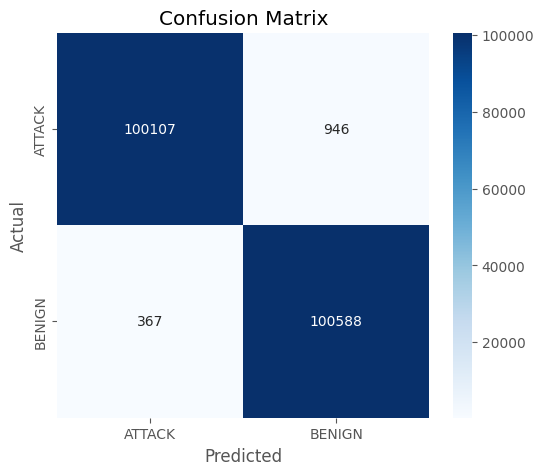

In [29]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le_label.classes_))

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print(f"[INFO] ROC-AUC Score: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_label.classes_, yticklabels=le_label.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 6. Feature Importance

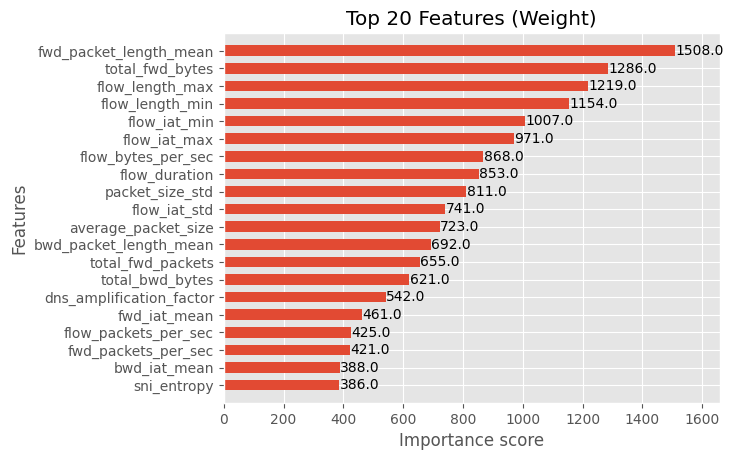

In [30]:
xgb.plot_importance(model, max_num_features=20, height=0.6)
plt.title('Top 20 Features (Weight)')
plt.show()

## 7. Save Model

In [32]:
# Save as PKL
with open("xgb_model_v2.1.pkl", "wb") as f:
    pickle.dump(model, f)

print("[INFO] Model saved to xgb_model_v2.1.pkl")

[INFO] Model saved to xgb_model_v2.1.pkl
